In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Gas Pipeline Flow Simulation Using Python

**Final Project**

**Author:** Petar Mihaylov  
**University:** SofUni (Software University)  
**Module:** Math Concepts for Developers – Online  
**Lecturer:** Yordan Darakchiev  

---

## Project Overview

This project demonstrates a mathematical and computational model of natural gas flow in pipelines using Python.

The objective is to analyze how different parameters influence gas transport in pipelines, including:

- Pressure drop along the pipeline
- Flow regime analysis using Reynolds number
- Influence of pipeline diameter and roughness
- Compressor station pressure recovery
- Simplified gas composition assumptions

The project combines **mathematical modeling**, **engineering intuition**, and **Python simulations** to visualize how gas pipelines behave under different operating conditions.
pressure losses, pipeline parameters, and compressor station effects.

# 1. Introduction

Gas pipelines are essential infrastructure in the energy industry. They transport natural gas over long distances from production facilities to consumers.

In pipeline systems, gas flow is influenced by several parameters:

- Pipeline length
- Pipe diameter
- Gas velocity
- Friction losses
- Pressure drop

Understanding how these parameters affect the flow is important for pipeline design and operation.

In this project we simulate gas flow in a pipeline using Python and basic physical equations.

# 2. Natural Gas Properties and Assumptions

Natural gas transported in pipelines is a mixture of hydrocarbons.

Typical composition:

Methane (CH4): 85–95 %  
Ethane (C2H6): 2–8 %  
Propane (C3H8): 0–3 %  
CO2 and N2: small amounts  

For simplicity, this model assumes constant gas density
representing typical pipeline natural gas.

Methane critical properties:

Critical temperature: 190.6 K  
Critical pressure: 4.6 MPa

Gas behavior near these conditions can deviate from ideal
gas assumptions. In this simplified model these effects
are not included.

# 3. Mathematical Model

Gas flowing in a pipeline experiences pressure loss due to friction with the pipe wall.

A simplified equation used in pipeline flow analysis is the Darcy–Weisbach equation:

ΔP = f * (L/D) * (ρ * v² / 2)

Where:

ΔP = pressure drop (Pa)  
f = friction factor  
L = pipe length (m)  
D = pipe diameter (m)  
ρ = gas density (kg/m³)  
v = gas velocity (m/s)

This equation allows us to estimate pressure losses in pipelines.

# 4. Pipeline Roughness and Friction Factor

Real pipelines are not perfectly smooth. Internal surface roughness increases turbulence and therefore increases friction losses.

Typical internal roughness values:

New steel pipeline: 0.045 mm  
Aged steel pipeline: up to 0.2 mm

The friction factor used in the Darcy–Weisbach equation depends on pipe roughness and Reynolds number.

One common relation used to estimate the friction factor in turbulent flow is the Colebrook equation.

In [18]:
# Pipeline parameters

length = 10000        # meters
diameter = 0.8        # meters
density = 0.8         # kg/m3 (approx natural gas)
friction_factor = 0.02

In [19]:
velocity = np.linspace(1, 20, 50)

In [20]:
pressure_drop = friction_factor * (length / diameter) * (density * velocity**2 / 2)

pressure_drop

array([  100.        ,   192.58642232,   315.24364848,   467.97167847,
         650.77051229,   863.64014994,  1106.58059142,  1379.59183673,
        1682.67388588,  2015.82673886,  2379.05039567,  2772.34485631,
        3195.71012078,  3649.14618909,  4132.65306122,  4646.23073719,
        5189.87921699,  5763.59850062,  6367.38858809,  7001.24947938,
        7665.18117451,  8359.18367347,  9083.25697626,  9837.40108288,
       10621.61599334, 11435.90170762, 12280.25822574, 13154.68554769,
       14059.18367347, 14993.75260308, 15958.39233653, 16953.1028738 ,
       17977.88421491, 19032.73635985, 20117.65930862, 21232.65306122,
       22377.71761766, 23552.85297793, 24758.05914202, 25993.33610995,
       27258.68388172, 28554.10245731, 29879.59183673, 31235.15201999,
       32620.78300708, 34036.484798  , 35482.25739275, 36958.10079134,
       38464.01499375, 40000.        ])

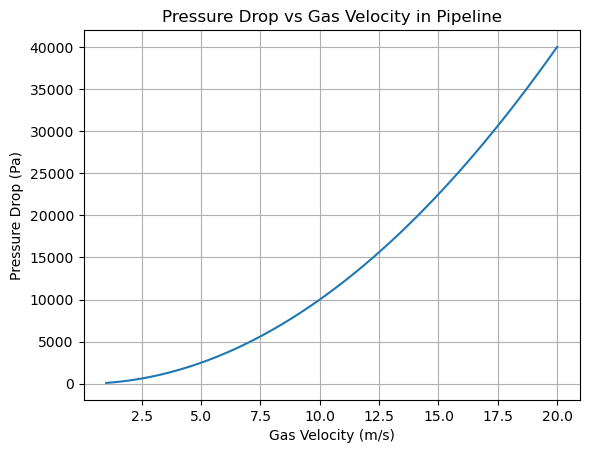

In [21]:
plt.figure()

plt.plot(velocity, pressure_drop)

plt.xlabel("Gas Velocity (m/s)")
plt.ylabel("Pressure Drop (Pa)")
plt.title("Pressure Drop vs Gas Velocity in Pipeline")

plt.grid(True)

plt.show()

# 5. Results and Discussion

The simulation shows that pressure drop increases rapidly with gas velocity.

This occurs because the Darcy–Weisbach equation contains a squared velocity term (v²).  
Higher gas velocities therefore lead to significantly higher pressure losses.

In real gas pipeline systems, operators must carefully control gas velocity to avoid excessive energy losses.

# 6. Pressure Profile Along the Pipeline

Engineers often analyze how pressure changes along the pipeline length.  
This is called the pressure profile.

The pressure gradually decreases from the inlet to the outlet due to friction losses.

In [24]:
initial_pressure = 5e6  # Pa (5 MPa)

distance = np.linspace(0, length, 100)

pressure_loss_per_meter = pressure_drop[-1] / length

pressure_profile = initial_pressure - pressure_loss_per_meter * distance

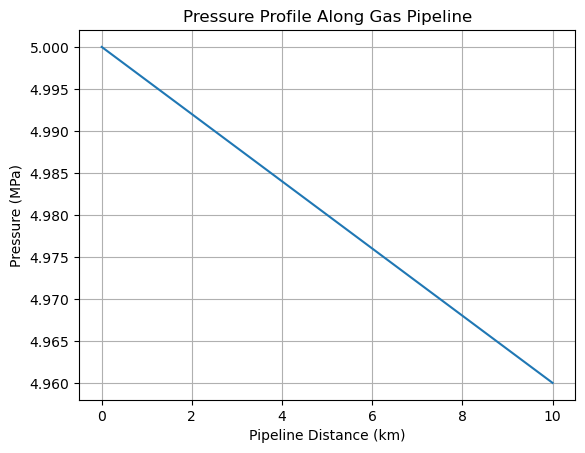

In [25]:
plt.figure()

plt.plot(distance/1000, pressure_profile/1e6)

plt.xlabel("Pipeline Distance (km)")
plt.ylabel("Pressure (MPa)")
plt.title("Pressure Profile Along Gas Pipeline")

plt.grid(True)

plt.show()

# 7. Pressure Profile Analysis

The pressure profile shows a gradual decrease along the pipeline length.

In long-distance gas transmission pipelines, compressor stations are installed periodically to restore pressure and maintain flow.

# 8. Influence of Pipeline Diameter

Pipeline diameter strongly affects pressure losses.

Larger diameters reduce gas velocity and therefore reduce friction losses.

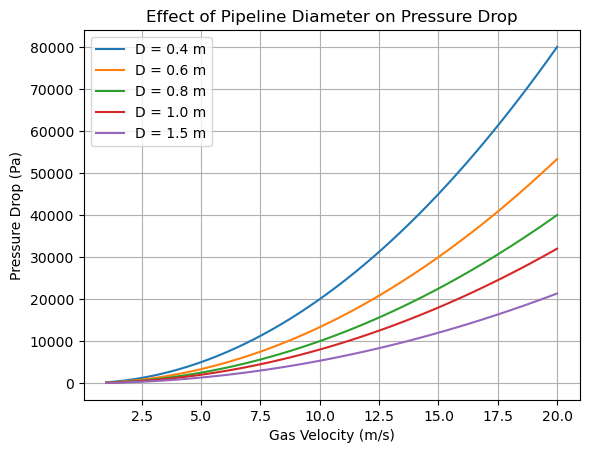

In [39]:
diameters = [0.4, 0.6, 0.8, 1.0, 1.5]

plt.figure()

for d in diameters:

    pressure_drop_d = friction_factor * (length / d) * (density * velocity**2 / 2)

    plt.plot(velocity, pressure_drop_d, label=f"D = {d} m")

plt.xlabel("Gas Velocity (m/s)")
plt.ylabel("Pressure Drop (Pa)")
plt.title("Effect of Pipeline Diameter on Pressure Drop")

plt.legend()
plt.grid(True)

plt.show()

# 9. Operational Constraints in Gas Pipelines

Gas transported in pipelines must meet strict quality specifications.

One important parameter is the water dew point.

If the gas temperature falls below the water dew point, condensation may occur inside the pipeline. This may lead to corrosion or hydrate formation.

For this reason natural gas is typically dehydrated before entering transmission pipelines.

# 10. Model Limitations

The current simulation contains several simplifications:

• Constant gas density  
• Constant friction factor  
• No temperature variation  
• No elevation effects  
• No compressor stations

Real pipeline simulations require more advanced thermodynamic and hydraulic models.

# 11. Conclusion

This project demonstrated how mathematical models and Python simulations can be used to analyze gas pipeline flow.

The simulation showed how velocity, diameter, and friction losses influence pressure drop in pipelines.

Although simplified, the model illustrates the fundamental principles governing natural gas transmission systems.

# 11. Flow Regime Analysis

The flow regime inside the pipeline can be characterized using the Reynolds number.

The Reynolds number is defined as:

Re = (ρ * v * D) / μ

Where:

ρ = gas density (kg/m³)  
v = gas velocity (m/s)  
D = pipe diameter (m)  
μ = dynamic viscosity (Pa·s)

Typical flow regimes:

Re < 2300 → Laminar flow  
2300 < Re < 4000 → Transitional flow  
Re > 4000 → Turbulent flow

Gas pipelines usually operate in the turbulent regime.

In [27]:
# dynamic viscosity of natural gas (approx)
viscosity = 1.1e-5   # Pa*s

reynolds_number = (density * velocity * diameter) / viscosity

reynolds_number

array([  58181.81818182,   80742.11502783,  103302.41187384,
        125862.70871985,  148423.00556586,  170983.30241187,
        193543.59925788,  216103.8961039 ,  238664.19294991,
        261224.48979592,  283784.78664193,  306345.08348794,
        328905.38033395,  351465.67717996,  374025.97402597,
        396586.27087199,  419146.567718  ,  441706.86456401,
        464267.16141002,  486827.45825603,  509387.75510204,
        531948.05194805,  554508.34879406,  577068.64564007,
        599628.94248609,  622189.2393321 ,  644749.53617811,
        667309.83302412,  689870.12987013,  712430.42671614,
        734990.72356215,  757551.02040816,  780111.31725417,
        802671.61410019,  825231.9109462 ,  847792.20779221,
        870352.50463822,  892912.80148423,  915473.09833024,
        938033.39517625,  960593.69202226,  983153.98886827,
       1005714.28571429, 1028274.5825603 , 1050834.87940631,
       1073395.17625232, 1095955.47309833, 1118515.76994434,
       1141076.06679035,

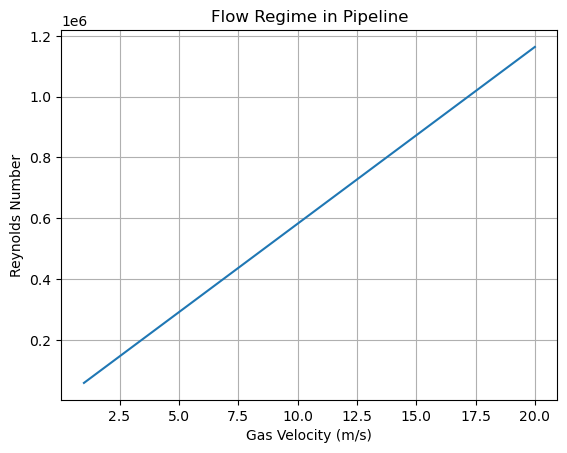

In [28]:
plt.figure()

plt.plot(velocity, reynolds_number)

plt.xlabel("Gas Velocity (m/s)")
plt.ylabel("Reynolds Number")
plt.title("Flow Regime in Pipeline")

plt.grid(True)

plt.show()

# 12. Flow Regime Discussion

The Reynolds number values obtained in the simulation are significantly higher than 4000.

This indicates turbulent flow inside the pipeline, which is typical for natural gas transmission systems.

In turbulent flow conditions, friction losses are influenced strongly by pipe roughness and velocity.

# 13. Compressor Station Simulation

In long-distance pipelines, compressor stations are installed to compensate for pressure losses.

Compressors increase gas pressure and maintain flow over long distances.

In this simplified model, a compressor station restores pressure to a higher level after a certain pipeline distance.

In [30]:
# compressor boost
compressor_boost = 2e6  # 2 MPa pressure increase

pressure_after_compressor = pressure_profile + compressor_boost

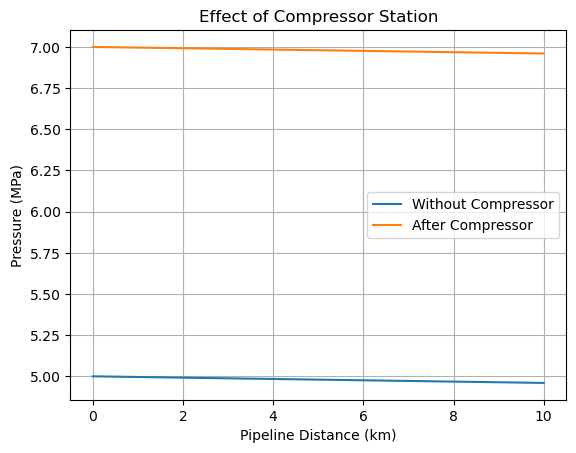

In [31]:
plt.figure()

plt.plot(distance/1000, pressure_profile/1e6, label="Without Compressor")

plt.plot(distance/1000, pressure_after_compressor/1e6, label="After Compressor")

plt.xlabel("Pipeline Distance (km)")
plt.ylabel("Pressure (MPa)")
plt.title("Effect of Compressor Station")

plt.legend()
plt.grid(True)

plt.show()

# 14. Compressor Station Discussion

The compressor increases gas pressure and compensates for friction losses along the pipeline.

In real transmission systems, compressor stations are typically installed every 100–200 km depending on pipeline diameter, gas flow rate, and terrain.

Compressor stations are critical infrastructure components that ensure stable and efficient gas transport.

# 15. Compressor Energy Considerations

Compressor stations are essential components in long-distance gas pipelines. 
Their purpose is to restore pressure losses caused by friction and maintain gas flow.

However, compressors require significant energy input.

The required power depends on several parameters:

• Gas flow rate  
• Compression ratio  
• Gas temperature  
• Compressor efficiency  

Higher pressure ratios require more energy and increase operational costs.

In real pipeline networks, compressor stations are optimized to balance energy consumption and transport efficiency.

# 16. Conclusion

This project presented a simplified mathematical model of natural gas pipeline flow using Python.

The simulation demonstrated several important principles of pipeline engineering:

• Pressure losses increase with gas velocity  
• Larger pipeline diameters significantly reduce friction losses  
• Pressure decreases gradually along the pipeline length  
• Turbulent flow dominates in typical gas transmission pipelines  
• Compressor stations are necessary to maintain pressure over long distances

Although the model uses simplified assumptions, it illustrates the fundamental relationships between pipeline parameters and gas flow behavior.

Future improvements could include temperature effects, variable gas composition, elevation changes, and more advanced thermodynamic models.

# 17. Interactive Pipeline Simulator

To better explore the behavior of the pipeline model, an interactive simulator was implemented.

The user can adjust pipeline length, diameter, and gas velocity to observe how these parameters affect pressure losses and the pressure profile along the pipeline.

In [34]:
!pip install ipywidgets

In [33]:
from ipywidgets import interact

In [35]:
def pipeline_simulator(length=10000, diameter=0.8, velocity=10):

    density = 0.8
    friction_factor = 0.02
    
    pressure_drop = friction_factor * (length / diameter) * (density * velocity**2 / 2)
    
    print(f"Pressure Drop: {pressure_drop/1e6:.3f} MPa")
    
    distance = np.linspace(0, length, 100)
    
    pressure_profile = 5e6 - (pressure_drop/length) * distance
    
    plt.figure()
    plt.plot(distance/1000, pressure_profile/1e6)
    
    plt.xlabel("Pipeline Distance (km)")
    plt.ylabel("Pressure (MPa)")
    plt.title("Pipeline Pressure Profile Simulation")
    plt.grid(True)
    
    plt.show()

In [37]:
interact(
    pipeline_simulator,
    length=(5000, 50000, 5000),
    diameter=(0.4, 1.2, 0.1),
    velocity=(1, 20, 1)
);

interactive(children=(IntSlider(value=10000, description='length', max=50000, min=5000, step=5000), FloatSlide…